#Survey Results

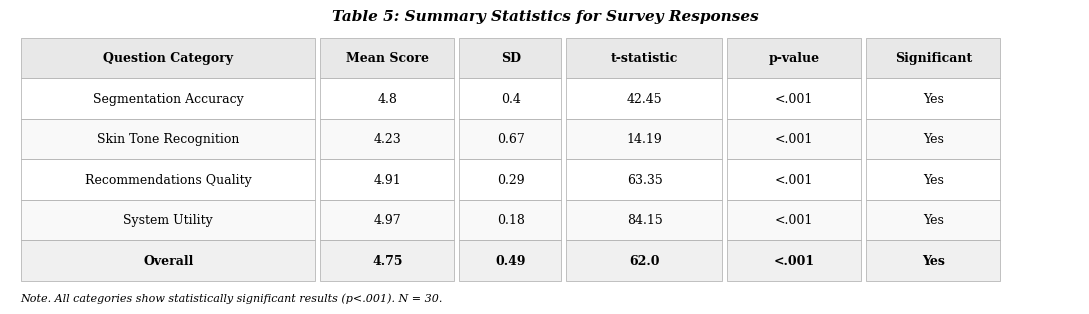

Saved as survey_table.png


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

# ── Data ──────────────────────────────────────────────────────────────────────
data = {
    'Q1_seg':          [5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,4,5,5,5,4,5],
    'Q2_skin':         [5,5,5,5,5,5,5,5,4,5,5,5,5,4,5,5,4,4,5,5,5,4,5,5,4,5,5,4,4,5],
    'Q3_lip':          [5,5,5,5,5,5,5,5,4,5,5,5,5,4,5,5,4,4,5,5,5,4,5,5,4,5,5,4,4,5],
    'Q4_monk':         [4,4,4,4,4,4,4,4,3,4,4,4,4,3,4,4,3,3,4,4,4,3,4,4,3,4,4,3,3,4],
    'Q5_undertone':    [5,5,5,5,5,5,5,5,4,5,5,5,5,4,5,5,4,4,5,5,5,4,5,5,4,5,5,4,4,5],
    'Q6_rec':          [5,5,5,5,5,5,5,5,4,5,5,5,5,4,5,5,4,4,5,5,5,4,5,5,4,5,5,4,4,5],
    'Q7_scores':       [5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5],
    'Q8_price':        [5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5],
    'Q9_understanding':[5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,4,5],
    'Q10_recommend':   [5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,4],
}
df = pd.DataFrame(data)

# ── Groups ────────────────────────────────────────────────────────────────────
groups = {
    'Segmentation Accuracy': ['Q1_seg', 'Q2_skin', 'Q3_lip'],
    'Skin Tone Recognition':  ['Q4_monk', 'Q5_undertone'],
    'Recommendations Quality':['Q6_rec', 'Q7_scores', 'Q8_price'],
    'System Utility':       ['Q9_understanding', 'Q10_recommend'],
}
neutral = 3

# ── Stats ─────────────────────────────────────────────────────────────────────
rows = []
for gname, gcols in groups.items():
    scores = df[gcols].values.flatten().astype(float)
    mean = np.mean(scores)
    sd   = np.std(scores, ddof=1)
    t, p = stats.ttest_1samp(scores, neutral)
    rows.append({'Category': gname, 'Mean': round(mean,2),
                 'SD': round(sd,2), 't': round(t,2), 'p': p})

all_scores = df.values.flatten().astype(float)
mean = np.mean(all_scores); sd = np.std(all_scores, ddof=1)
t, p = stats.ttest_1samp(all_scores, neutral)
rows.append({'Category': 'Overall', 'Mean': round(mean,2),
             'SD': round(sd,2), 't': round(t,2), 'p': p})

results = pd.DataFrame(rows)
results['p_fmt'] = results['p'].apply(lambda x: '<.001' if x < 0.001 else f'{x:.3f}')
results['Sig']   = 'Yes'

# ── Table Figure ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.axis('off')

col_labels = ['Question Category', 'Mean Score', 'SD', 't-statistic', 'p-value', 'Significant']
table_data = results[['Category','Mean','SD','t','p_fmt','Sig']].values.tolist()

# Title above table
fig.text(0.5, 0.97, 'Table 5: Summary Statistics for Survey Responses',
         ha='center', va='top', fontsize=11, fontweight='bold', style='italic',
         fontfamily='serif')

col_widths = [0.28, 0.13, 0.10, 0.15, 0.13, 0.13]
x_positions = [0.01]
for w in col_widths[:-1]:
    x_positions.append(x_positions[-1] + w)

row_height = 0.14
header_y  = 0.78
header_bg = '#E8E8E8'

# Header
for i, (label, x, w) in enumerate(zip(col_labels, x_positions, col_widths)):
    ax.add_patch(FancyBboxPatch((x, header_y), w - 0.005, row_height,
                                boxstyle="square,pad=0", linewidth=0.5,
                                edgecolor='#AAAAAA', facecolor=header_bg,
                                transform=ax.transAxes))
    ax.text(x + w/2 - 0.002, header_y + row_height/2, label,
            ha='center', va='center', fontsize=9, fontweight='bold',
            fontfamily='serif', transform=ax.transAxes)

# Rows
row_colors = ['#FFFFFF', '#F9F9F9']
for r_idx, row in enumerate(table_data):
    y = header_y - (r_idx + 1) * row_height
    is_last = (r_idx == len(table_data) - 1)
    for i, (val, x, w) in enumerate(zip(row, x_positions, col_widths)):
        bg = '#F0F0F0' if is_last else row_colors[r_idx % 2]
        ax.add_patch(FancyBboxPatch((x, y), w - 0.005, row_height,
                                    boxstyle="square,pad=0", linewidth=0.5,
                                    edgecolor='#AAAAAA', facecolor=bg,
                                    transform=ax.transAxes))
        ax.text(x + w/2 - 0.002, y + row_height/2, str(val),
                ha='center', va='center', fontsize=9,
                fontweight='bold' if is_last else 'normal',
                fontfamily='serif', transform=ax.transAxes)

# Note below table
note_y = header_y - len(table_data) * row_height - 0.04
ax.text(0.01, note_y,
        'Note. All categories show statistically significant results (p<.001). N = 30.',
        ha='left', va='top', fontsize=8, style='italic',
        fontfamily='serif', transform=ax.transAxes)

plt.tight_layout()
plt.savefig('survey_table.png', dpi=200, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print("Saved as survey_table.png")